# Exploratory Data Analysis – Superstore Dataset

## Project Overview

This project performs Exploratory Data Analysis (EDA) on the Superstore dataset using Python, Pandas, Matplotlib, and Seaborn.

### Objectives

- Understand the structure of the dataset
- Calculate summary statistics
- Analyze sales and profit
- Identify patterns and outliers
- Compare sales across categories and regions
- Extract meaningful business insights

## 1. Dataset Overview

The Superstore dataset contains information about customer orders, products, sales, discounts, and profits.

The analysis includes data inspection, summary statistics, data quality checks, and visualization of important business metrics.

In [1]:
print("My EDA project has started!") 

My EDA project has started!


In [3]:
import pandas as pd

df = pd.read_csv("data/Sample - Superstore.csv", encoding="latin1")

print("Dataset loaded successfully!")
print("Rows and columns:", df.shape)

Dataset loaded successfully!
Rows and columns: (9994, 21)


In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print("Dates converted successfully!")

Dates converted successfully!


In [9]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
!pip install seaborn

In [29]:
import seaborn as sns
print("Seaborn is working!")

Seaborn is working!


## Sales by Category – Seaborn Visualization

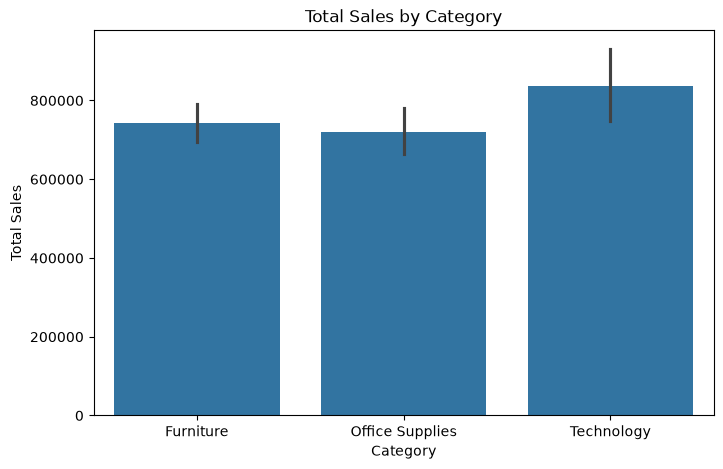

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(data=df, x="Category", y="Sales", estimator=sum)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

### Observation

Technology has the highest total sales among the three categories, followed by Furniture and Office Supplies.

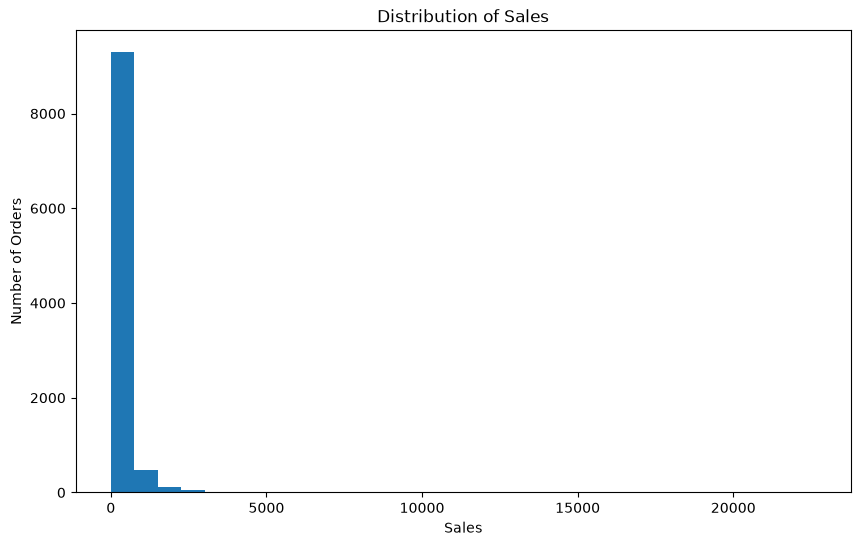

In [18]:
plt.figure(figsize=(10, 6))

plt.hist(df["Sales"], bins=30)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Number of Orders")

plt.show()

### Observation

Most orders have relatively low sales values, while a small number of orders have very high sales. This indicates that the sales distribution is right-skewed.

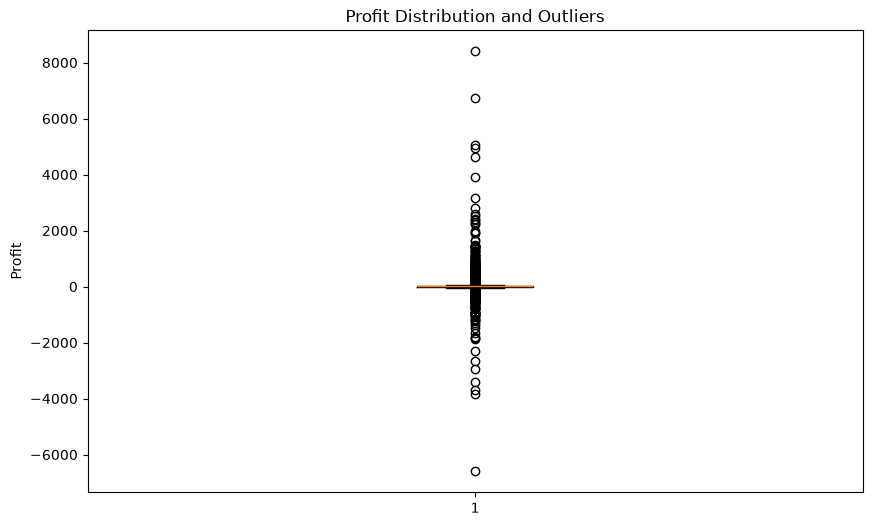

In [13]:
plt.figure(figsize=(10, 6))

plt.boxplot(df["Profit"])

plt.title("Profit Distribution and Outliers")
plt.ylabel("Profit")

plt.show()

### Observation

Profit varies considerably across orders, with some unusually high and low values. The presence of extreme values indicates potential profit outliers.

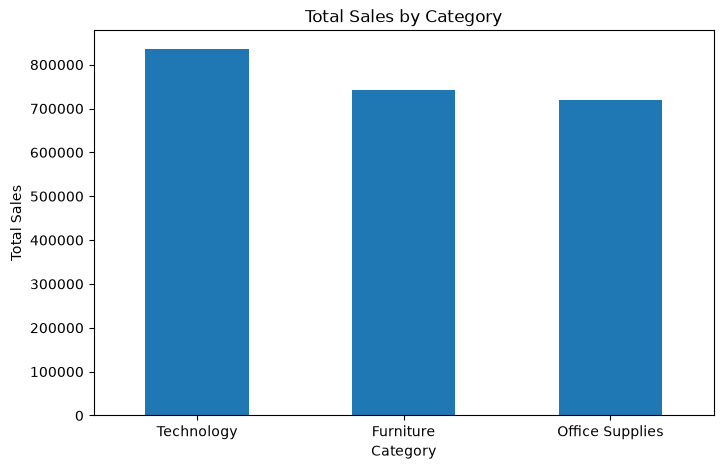

In [14]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)
plt.show()

### Observation

Technology generates the highest total sales among the three product categories, while Office Supplies and Furniture contribute lower total sales.

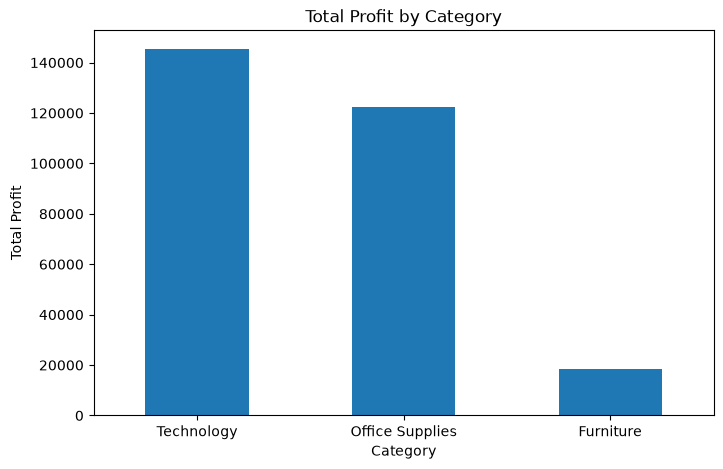

In [15]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

category_profit.plot(kind="bar")

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.xticks(rotation=0)
plt.show()

### Observation

Technology generates the highest total profit, while Furniture has comparatively lower profitability. This shows that high sales do not always translate equally into profit.

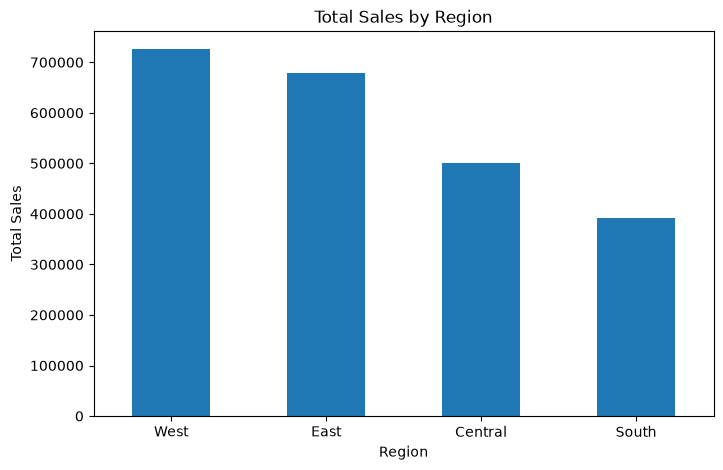

In [16]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)
plt.show()

### Observation

The West region generates the highest total sales, while the other regions contribute different levels of sales. This indicates regional differences in sales performance.

# Top 3 Insights

1. Technology is the strongest-performing category because it contributes the highest overall sales and profit.

2. Sales and profit are unevenly distributed, with most orders having relatively small values and a few orders having very high or extreme values.

3. Regional performance differs, with the West region generating the highest total sales.

# Conclusion

The exploratory data analysis of the Superstore dataset helped identify important patterns in sales and profit. Technology is a strong-performing category, sales vary significantly across orders, and regional performance differs. The visualizations and summary statistics provide useful insights into the overall business performance.